 # 1. Extraction

Carga del dataset y reportes generales.


In [88]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

Cargar y visualizar el dataset:


In [89]:
df = pd.read_csv("metro_data.csv")
df.head()

,fecha,mes,anio,linea,estacion,tipo_pago,afluencia
0,2021-01-01,Enero,2021,LÃ­nea 1,Balbuena,Boleto,1848
1,2021-01-01,Enero,2021,LÃ­nea 1,Balbuena,Prepago,790
2,2021-01-01,Enero,2021,LÃ­nea 1,Balbuena,Gratuidad,325
3,2021-01-01,Enero,2021,LÃ­nea 1,Balderas,Boleto,1103
4,2021-01-01,Enero,2021,LÃ­nea 1,Balderas,Prepago,922


In [90]:
df.isna().sum()

fecha        0
mes          0
anio         0
linea        0
estacion     0
tipo_pago    0
afluencia    0
dtype: int64

1. Columnas


In [91]:
cols = df.columns
print("Las columnas son: ", list(cols)," que en total son", len(cols), "Columnas!!")

Las columnas son:  ['fecha', 'mes', 'anio', 'linea', 'estacion', 'tipo_pago', 'afluencia']  que en total son 7 Columnas!!


2. Descripcion general del dataset


In [92]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1192230 entries, 0 to 1192229
Data columns (total 7 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   fecha      1192230 non-null  str  
 1   mes        1192230 non-null  str  
 2   anio       1192230 non-null  int64
 3   linea      1192230 non-null  str  
 4   estacion   1192230 non-null  str  
 5   tipo_pago  1192230 non-null  str  
 6   afluencia  1192230 non-null  int64
dtypes: int64(2), str(5)
memory usage: 63.7 MB


# 2. Transformation


Limpieza de columnas

El mes y el tipo de pago no nos gustan en string, mejor vamos a dummies(one hot encoding)


In [93]:
print(df["mes"].unique())
print(df["tipo_pago"].unique())

<StringArray>
[     'Enero',    'Febrero',      'Marzo',      'Abril',       'Mayo',
      'Junio',      'Julio',     'Agosto', 'Septiembre',    'Octubre',
  'Noviembre',  'Diciembre']
Length: 12, dtype: str
<StringArray>
['Boleto', 'Prepago', 'Gratuidad']
Length: 3, dtype: str


In [94]:
encoded_df = pd.get_dummies(df, columns = ["mes", "tipo_pago"], drop_first=True)

Ahora hacemos limpieza sobre la columna de linea y estacion. Compenzamos con la columna linea, y es que si nos fijamos en todas las lineas que hay, algunas son las mismas pero escritas de diferente manera. Asi que vamos a unificarlas para que no haya duplicados de la misma linea.


In [95]:
encoded_df['linea'].unique()

<StringArray>
[ 'LÃ­nea 1', 'LÃ­nea 12',  'LÃ­nea 2',  'LÃ­nea 3',  'LÃ­nea 4',  'LÃ­nea 5',
  'LÃ­nea 6',  'LÃ­nea 7',  'LÃ­nea 8',  'LÃ­nea 9',  'LÃ­nea A',  'LÃ­nea B',
   'Linea 1',   'Linea 2',   'Linea 3',   'Linea 4',   'Linea 5',   'Linea 6',
   'Linea 7',   'Linea 8',   'Linea 9',   'Linea A',   'Linea B',  'Linea 12']
Length: 24, dtype: str

Los caracteres especiales no los queremos, asi que usaremos el estandar "Linea x" para juntar nombres.


In [96]:
encoded_df["linea"] = encoded_df["linea"].replace({"LÃ­nea 1": "Linea 1", "LÃ­nea 2": "Linea 2",
"LÃ­nea 3": "Linea 3","LÃ­nea 4": "Linea 4","LÃ­nea 5": "Linea 5",
"LÃ­nea 6": "Linea 6","LÃ­nea 8": "Linea 8","LÃ­nea 9": "Linea 9",
"LÃ­nea A": "Linea A","LÃ­nea B": "Linea B","LÃ­nea 12": "Linea 12",
"LÃ­nea 7": "Linea 7",})

In [97]:
encoded_df["linea"].unique()

<StringArray>
[ 'Linea 1', 'Linea 12',  'Linea 2',  'Linea 3',  'Linea 4',  'Linea 5',
  'Linea 6',  'Linea 7',  'Linea 8',  'Linea 9',  'Linea A',  'Linea B']
Length: 12, dtype: str

Como no los queremos hacer dummies por que van a ser 12 columnas mas, mejor solo los ponemos como categorias por el momento para ir viendo.


In [98]:
encoded_df["linea"] = encoded_df["linea"].astype("category")

Para ver las estaciones, los hacemos una lista y lo ordenamos en orden alfabético para facilitar la busqueda de duplicados.


In [99]:
sorted(encoded_df["estacion"].unique().tolist())

['Acatitla',
 'Aculco',
 'AgrÃ\xadcola Oriental',
 'Allende',
 'Apatlaco',
 'Aquiles SerdÃ¡n',
 'AragÃ³n',
 'Atlalilco',
 'Auditorio',
 'Autobuses del Norte',
 'Balbuena',
 'Balderas',
 'Barranca del Muerto',
 'Bellas Artes',
 'Bondojito',
 'Bosque de AragÃ³n',
 'Boulevard Puerto AÃ©reo',
 'Buenavista',
 'Calle 11',
 'Camarones',
 'Canal de San Juan',
 'Canal del Norte',
 'Candelaria',
 'Centro MÃ©dico',
 'Cerro de la Estrella',
 'Chabacano',
 'Chapultepec',
 'Chilpancingo',
 'Ciudad Azteca',
 'Ciudad Deportiva',
 'Colegio Militar',
 'ConstituciÃ³n de 1917',
 'Constituyentes',
 'Consulado',
 'Copilco',
 'CoyoacÃ¡n',
 'Coyuya',
 'Cuatro Caminos',
 'CuauhtÃ©moc',
 'CuitlÃ¡huac',
 'CulhuacÃ¡n',
 'Deportivo 18 de Marzo',
 'Deportivo OceanÃ\xada',
 'DivisiÃ³n del Norte',
 'Doctores',
 'Ecatepec',
 'Eduardo Molina',
 'Eje Central',
 'El Rosario',
 'Ermita',
 'EscuadrÃ³n 201',
 'EtiopÃ\xada/Plaza de la Transparencia',
 'Eugenia',
 'FerrerÃ\xada/Arena Ciudad de MÃ©xico',
 'Fray Servando',
 'Ga

Explorando los resultados de estaciones podemos ver que los que se repiten son:
 - "Villa de CortÃ©s": "Villa de Cortés"
 - "OlÃ\xadmpica": "Olímpica"
 - "PeÃ±Ã³n viejo": "PeÃ±Ã³n Viejo"
 - "Miguel Ã\x81ngel de Quevedo": "Miguel Ángel de Quevedo"
 - "GÃ³mez FarÃ\xadas": "GÃ³mez Farias"


In [100]:
encoded_df["estacion"] = encoded_df["estacion"].replace({"Villa de CortÃ©s": "Villa de Cortés", 
"OlÃ\xadmpica": "Olímpica", "PeÃ±Ã³n viejo": "PeÃ±Ã³n Viejo",
"Miguel Ã\x81ngel de Quevedo": "Miguel Ángel de Quevedo", "GÃ³mez FarÃ\xadas": "GÃ³mez Farias"})

print(len(df["estacion"].unique()))
print(len(encoded_df["estacion"].unique()))

168
163


Con esto eliminamos las 5 estaciones que estaban duplicadas. Como el texto nos quedo feo y no lo arreglamos desde un inicio, codificamos y decodificamos el texto para que nos quede como lo puede leer un humano mortal. Para ello hacemos una funcion que arregle el texto por cada fila del dataset, como algunos textos si se codificaron de manera correcta, tenemos que evitar que los vuelva a decodificar para que no tenga errores, es por eso que la funcion lleva un try que verifique si necesita decodificacion o no.


In [101]:
def arreglar_texto(texto):
    try:
        return texto.encode('latin1').decode('utf-8')
    except (UnicodeEncodeError, UnicodeDecodeError):
        return texto

encoded_df["estacion"] = encoded_df["estacion"].apply(arreglar_texto)
sorted(encoded_df["estacion"].unique().tolist())

['Acatitla',
 'Aculco',
 'Agrícola Oriental',
 'Allende',
 'Apatlaco',
 'Aquiles Serdán',
 'Aragón',
 'Atlalilco',
 'Auditorio',
 'Autobuses del Norte',
 'Balbuena',
 'Balderas',
 'Barranca del Muerto',
 'Bellas Artes',
 'Bondojito',
 'Bosque de Aragón',
 'Boulevard Puerto Aéreo',
 'Buenavista',
 'Calle 11',
 'Camarones',
 'Canal de San Juan',
 'Canal del Norte',
 'Candelaria',
 'Centro Médico',
 'Cerro de la Estrella',
 'Chabacano',
 'Chapultepec',
 'Chilpancingo',
 'Ciudad Azteca',
 'Ciudad Deportiva',
 'Colegio Militar',
 'Constitución de 1917',
 'Constituyentes',
 'Consulado',
 'Copilco',
 'Coyoacán',
 'Coyuya',
 'Cuatro Caminos',
 'Cuauhtémoc',
 'Cuitláhuac',
 'Culhuacán',
 'Deportivo 18 de Marzo',
 'Deportivo Oceanía',
 'División del Norte',
 'Doctores',
 'Ecatepec',
 'Eduardo Molina',
 'Eje Central',
 'El Rosario',
 'Ermita',
 'Escuadrón 201',
 'Etiopía/Plaza de la Transparencia',
 'Eugenia',
 'Ferrería/Arena Ciudad de México',
 'Fray Servando',
 'Garibaldi/Lagunilla',
 'General

De acuerdo a la página oficial del metro Ciudad de México, hay 195 estaciones, las cuales son 32 más de las reportadas en el dataset. 

Ahora cambiamos la fecha que esta en string a datetime.


In [102]:
encoded_df["fecha"] = pd.to_datetime(encoded_df["fecha"])

Ahora arreglamos el dataset de forma que las variables con baja cardinalidad tengamos como categorias y como dummies para analsis ML.


In [103]:
encoded_df["estacion"] = encoded_df["estacion"].astype("category")
encoded_df["mes"] = df["mes"]
encoded_df["tipo_pago"] = df["tipo_pago"]
encoded_df[["mes", "tipo_pago"]] = encoded_df[["mes", "tipo_pago"]].astype("category")
encoded_df["Linea"] = encoded_df["linea"]
encoded_df = pd.get_dummies(encoded_df, columns=["linea"], prefix="Linea", drop_first=True)
encoded_df["year"] = encoded_df["anio"]
encoded_df = pd.get_dummies(encoded_df, columns=["anio"], prefix="year", drop_first=True)

Ahora, la unica columna que falta de modificar es la de estacion.


In [104]:
encoded_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1192230 entries, 0 to 1192229
Data columns (total 36 columns):
 #   Column               Non-Null Count    Dtype         
---  ------               --------------    -----         
 0   fecha                1192230 non-null  datetime64[us]
 1   estacion             1192230 non-null  category      
 2   afluencia            1192230 non-null  int64         
 3   mes_Agosto           1192230 non-null  bool          
 4   mes_Diciembre        1192230 non-null  bool          
 5   mes_Enero            1192230 non-null  bool          
 6   mes_Febrero          1192230 non-null  bool          
 7   mes_Julio            1192230 non-null  bool          
 8   mes_Junio            1192230 non-null  bool          
 9   mes_Marzo            1192230 non-null  bool          
 10  mes_Mayo             1192230 non-null  bool          
 11  mes_Noviembre        1192230 non-null  bool          
 12  mes_Octubre          1192230 non-null  bool          
 13  mes_Sept

Analisis Rapido
Aafluencia comenzando desde el 2021, saliendo de pandemia.


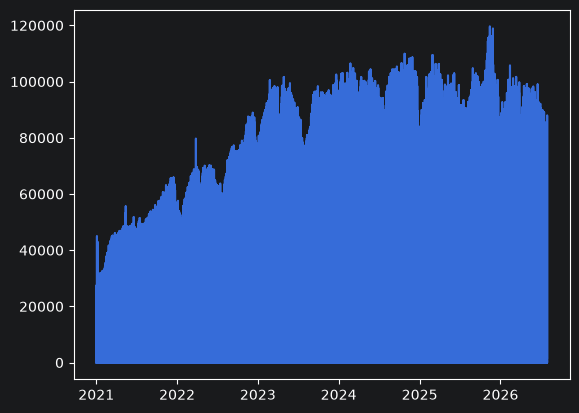

In [105]:
x = encoded_df["fecha"]
y = encoded_df["afluencia"]
plt.plot(x, y)
plt.show()


Para ver la fluencia por cada linea de manera individual, sumamos y agrupamos por linea.

In [106]:
afluencia_linea = encoded_df.groupby([
    "fecha", "Linea"])['afluencia'].sum().reset_index()

Como se veía muy amontonado, en lugar de que sea diário, lo juntamos por mes.

In [107]:
afluencia_suavizada = encoded_df.groupby([
    'Linea', 
    pd.Grouper(key='fecha', freq='ME')
])['afluencia'].mean().reset_index()

In [108]:
import seaborn as sns

Aafluencia por linea de metro, vemos que la linea 12 estuvo mas de medio año deshabilitada. 


<Axes: xlabel='fecha', ylabel='afluencia'>

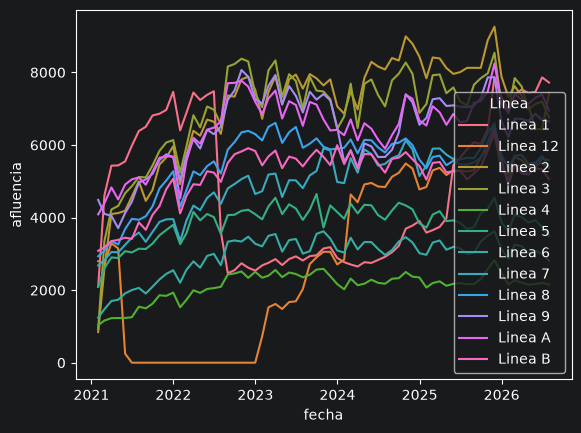

In [109]:
x = afluencia_suavizada["fecha"]
y = afluencia_suavizada["afluencia"]
h = afluencia_suavizada["Linea"]
sns.lineplot(x = x, y = y, hue = h)

Ahora vamos a ver un poquito de info que nos pueden decir las estaciones.


In [110]:
encoded_df.groupby(["estacion"])["afluencia"].sum().sort_values(ascending=False).head(10)

estacion
Pantitlán               275264936
Constitución de 1917    173161499
Indios Verdes           164830087
Cuatro Caminos          140736793
Tacubaya                132262168
Tasqueña                101966916
Buenavista               91314049
Universidad              91018012
Pino Suárez              90264339
Ciudad Azteca            77766813
Name: afluencia, dtype: int64

Claramente la estacion de Pantitlán tiene la mayor afluencia, sacando mas de 100000000 de personas a la estacion con segunda mayor afluencia. Valores tan separados tendran un impacto que veremos mas adelante cuando apliquemos los modelos.

In [111]:
(encoded_df['afluencia'] == 0).groupby(encoded_df["Linea"]).sum().reset_index()

,Linea,afluencia
0,Linea 1,50139
1,Linea 12,72094
2,Linea 2,28031
3,Linea 3,22040
4,Linea 4,10859
5,Linea 5,13759
6,Linea 6,12032
7,Linea 7,16950
8,Linea 8,19476
9,Linea 9,14405


In [112]:
(encoded_df["afluencia"] == 0).sum()

np.int64(291457)

Los ceros en la columna de afluencia pueden significar varias cosas:

- Cierre por mantenimiento de estacion
- Inundaciones
- Cierre por mantenimiento de linea
- Accidentes
- Remodelaciones
- Sin registro(poco probable)

Como podemos ver, la suma de las veces que la estacion estaba cerrada(0 aafluencia) nos dice que 285000 datos que faltan, aunado a esto tenemos una linea que estaba cerrada, lo cual es informacion relevante al momento de predecir la afluencia. El hecho de que la aafluencia sea 0, si importa ya que nos dice cada que la estacin esta cerrada(o cualquiera de las opciones mencionadas anteriormente) por lo tanto no lo podemos eliminar por que si, asi que, ponderemos una variable dummy que nos diga 1(aafluencia = 0) y 0(aafluencia > 0).


In [113]:

# en caso de que los 0 sean nan.
# encoded_df["estacion_estado"] = encoded_df["afluencia"].isnull().map({False: "estacion_cerrada", True: "estacion_abierta"}).astype("category")
encoded_df["estacion_estado"] = np.where(
    encoded_df["afluencia"] == 0, 
    "estacion_cerrada", 
    "estacion_abierta"
)
encoded_df["estacion_estado"] = encoded_df["estacion_estado"].astype("category")


Ahora que tenemos etiquetas para cuando la estacion esta cerrada, la podemos hacer dummy para el modelo.


In [114]:
encoded_df = pd.get_dummies(encoded_df, columns = ["estacion_estado"], drop_first=True)

### Rupturas estructurales y construcción de variables

Ahora sí identificamos las rupturas estructurales reales del periodo (cierres de estación, ramp de recuperación pos-COVID, cambio de producto de pago) y decidimos, con evidencia, si se excluyen, se dejan como bandera o se modelan tal cual. Después construimos variables de festivo y clima y las auditamos con un modelo rápido antes de seguir con la comparación de encodings.

In [115]:
grp = encoded_df.groupby(["fecha", "Linea", "estacion"])["afluencia"].agg(n_zero=lambda s: (s == 0).sum(), n_total="count")
cierres_completos = set(grp[grp["n_zero"] == grp["n_total"]].index)

key_tuples = list(zip(encoded_df["fecha"], encoded_df["Linea"], encoded_df["estacion"]))
encoded_df["es_cierre_completo"] = [k in cierres_completos for k in key_tuples]

print(f"Combinaciones (fecha, linea, estacion) con cierre completo: {len(cierres_completos)}")
print(f"Filas marcadas como cierre completo: {encoded_df['es_cierre_completo'].sum()} de {len(encoded_df)}")

cierres_df = pd.Series(list(cierres_completos)).apply(pd.Series).rename(columns={0: "fecha", 1: "Linea", 2: "estacion"})
print("\nCierres completos por línea:")
print(cierres_df["Linea"].value_counts())

Combinaciones (fecha, linea, estacion) con cierre completo: 29740
Filas marcadas como cierre completo: 89220 de 1192230

Cierres completos por línea:
Linea
Linea 12    15570
Linea 1     11381
Linea 2      1178
Linea 9       826
Linea 3       526
Linea 7       141
Linea 5        39
Linea 6        34
Linea 4        32
Linea B        12
Linea 8         1
Name: count, dtype: int64


In [116]:
for linea_top in cierres_df["Linea"].value_counts().head(2).index:
    sub = cierres_df[cierres_df["Linea"] == linea_top]
    print(f"{linea_top}: {sub['fecha'].min().date()} -> {sub['fecha'].max().date()}  ({len(sub)} estación-días)")

Linea 12: 2021-05-04 -> 2024-01-29  (15570 estación-días)
Linea 1: 2021-01-09 -> 2026-03-08  (11381 estación-días)


La inmensa mayoría de los cierres de estación completa se concentran en dos líneas: **Línea 12** (15,570 estación-días, del 2021-05-04 al 2024-01-29) y **Línea 1** (11,381 estación-días, con extremos del 2021-01-09 al 2026-03-08). El rango de Línea 12 coincide casi exactamente con el cierre real del tramo elevado tras el colapso estructural de mayo de 2021, reabierto por etapas hasta 2024 — la misma causa que documenta `script.ipynb`. El rango de Línea 1 es más amplio en sus extremos porque mezcla varias sub-rachas: el grueso corresponde previsiblemente a la modernización integral de la línea (concentrada 2023-2025, igual que en `script.ipynb`), con cierres puntuales adicionales en los extremos (enero 2021, semáforo epidemiológico rojo; 2026, mantenimiento por tramos) que amplían el mínimo/máximo sin ser el patrón dominante. El resto (Líneas 2, 9, 3, 7, 5, 6, 4, B) suma 1,789 estación-días dispersos — cierres puntuales de menor escala, no rupturas estructurales mayores.


**Decisión.** Estas combinaciones (fecha, línea, estación) con las tres tipos de pago en cero representan estación no operativa, no demanda real — se **excluyen** del dataset de modelado (misma decisión que la causa 1+2 de cierre estructural). Con esto, la bandera `estacion_estado_estacion_cerrada` que ya construimos arriba (marca *cualquier* fila con afluencia==0) queda correctamente acotada después de esta exclusión: las filas que sigan con esa bandera en 1 son el caso genuino de "un solo tipo de pago en cero, estación operando" — la causa que sí se conserva como señal válida.

In [117]:
n_antes = len(encoded_df)
encoded_df = encoded_df.loc[~encoded_df["es_cierre_completo"]].drop(columns="es_cierre_completo").copy()
n_despues = len(encoded_df)
print(f"Filas excluidas por cierre estructural completo: {n_antes - n_despues} ({(n_antes-n_despues)/n_antes:.2%})")
print("forma de encoded_df tras excluir cierres:", encoded_df.shape)

Filas excluidas por cierre estructural completo: 89220 (7.48%)
forma de encoded_df tras excluir cierres: (1103010, 37)


In [118]:
encoded_df["is_covid_recovery"] = ((encoded_df["fecha"] >= "2021-01-01") & (encoded_df["fecha"] <= "2021-06-30")).astype(int)

**Cambio de producto de pago (Boleto de papel → Prepago).** Esta también es una ruptura estructural real, pero a diferencia de un enfoque que agrega los tres tipos de pago en un solo total (donde hay que reconstruir a mano la razón Boleto/Prepago para no dejar que el modelo "haga trampa" aprendiendo una identidad contable), aquí `tipo_pago` ya quedó como variable dummy desde el primer paso de limpieza (`tipo_pago_Gratuidad`, `tipo_pago_Prepago`). El modelo ve cada fila con su tipo de pago explícito, así que la desaparición del boleto de papel simplemente es una relación fecha↔tipo_pago↔afluencia más que el modelo puede aprender directamente — no requiere tratamiento especial adicional aquí.

In [119]:
totales_mensuales = encoded_df.groupby(encoded_df["fecha"].dt.to_period("M"))["afluencia"].sum()
print(totales_mensuales.tail(18))

fecha
2025-02     94273723
2025-03    104863384
2025-04     97589918
2025-05    104309186
2025-06    100152730
2025-07    103165584
2025-08    105741529
2025-09    105273705
2025-10    115572139
2025-11    120635447
2025-12    107239178
2026-01    100789164
2026-02     98627598
2026-03    107426886
2026-04    100380478
2026-05    103936258
2026-06    101605071
2026-07    103731688
Freq: M, Name: afluencia, dtype: int64


Los totales mensuales de 2025-02 a 2026-07 se mueven en una banda de ~94 M a ~121 M pasajeros sin una caída visible alrededor de mayo de 2025 (94M feb → 105M mar → 98M abr → 104M may → 100M jun → 103M jul...) — no hay una discontinuidad clara atribuible al aumento de tarifa. Se documenta como una ruptura *buscada pero no confirmada* con la evidencia disponible, igual que en `script.ipynb`.


### Construcción de variables: festivos y clima

Cruzamos dos fuentes externas por fecha: días festivos oficiales de México (librería `holidays`) y clima diario de CDMX (`weather_cdmx.csv`, ya descargado previamente de Open-Meteo). Después las auditamos con un modelo rápido, comparando con y sin cada grupo, antes de decidir si valen la pena.

In [120]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score, mean_absolute_error
import holidays

In [121]:
anio_min, anio_max = encoded_df["fecha"].dt.year.min(), encoded_df["fecha"].dt.year.max()
mx_holidays = holidays.Mexico(years=range(anio_min, anio_max + 1))
holiday_dates = set(pd.Timestamp(d) for d in mx_holidays.keys())
encoded_df["is_holiday"] = encoded_df["fecha"].isin(holiday_dates).astype(int)

weather = pd.read_csv("weather_cdmx.csv", parse_dates=["fecha"])
encoded_df = encoded_df.merge(weather, on="fecha", how="left")
print("nulos tras el cruce de clima:", encoded_df[["temp_max_c", "temp_min_c", "precip_mm"]].isnull().sum().sum())

nulos tras el cruce de clima: 0


In [122]:
audit_df = encoded_df.copy()
audit_df["estacion_freq_tmp"] = audit_df["estacion"].map(audit_df["estacion"].value_counts())
audit_df[["temp_max_c", "temp_min_c", "precip_mm"]] = audit_df[["temp_max_c", "temp_min_c", "precip_mm"]].fillna(
    audit_df[["temp_max_c", "temp_min_c", "precip_mm"]].median()
)

base_cols = [c for c in audit_df.columns if c.startswith(("mes_", "tipo_pago_", "Linea_"))]
base_cols += ["year", "estacion_estado_estacion_cerrada", "estacion_freq_tmp"]
new_cols = ["is_holiday", "temp_max_c", "temp_min_c", "precip_mm", "is_covid_recovery"]

Xa = audit_df[base_cols + new_cols].copy()
ya = audit_df["afluencia"]
Xa_train, Xa_test, ya_train, ya_test = train_test_split(Xa, ya, test_size=0.2, shuffle=False)

num_cols_a = ["year", "estacion_freq_tmp", "temp_max_c", "temp_min_c", "precip_mm"]
sc_a = StandardScaler()
Xa_train[num_cols_a] = sc_a.fit_transform(Xa_train[num_cols_a])
Xa_test[num_cols_a] = sc_a.transform(Xa_test[num_cols_a])

grupos_a_auditar = {
    "festivos (is_holiday)": ["is_holiday"],
    "clima (temp_max, temp_min, precip)": ["temp_max_c", "temp_min_c", "precip_mm"],
    "bandera recuperación COVID (is_covid_recovery)": ["is_covid_recovery"],
}

def audit_fit(cols, label):
    m = LinearRegression().fit(Xa_train[cols], ya_train)
    pred = m.predict(Xa_test[cols])
    r2 = r2_score(ya_test, pred)
    mae = mean_absolute_error(ya_test, pred)
    print(f"{label:55s} R2={r2:.4f}  MAE={mae:10.1f}")
    return r2

full_cols = list(Xa.columns)
r2_full = audit_fit(full_cols, "modelo completo (con festivo, clima, covid)")
for nombre, cols in grupos_a_auditar.items():
    sin_cols = [c for c in full_cols if c not in cols]
    audit_fit(sin_cols, f"sin {nombre}")

modelo completo (con festivo, clima, covid)             R2=0.4128  MAE=    4490.5
sin festivos (is_holiday)                               R2=0.4116  MAE=    4483.4
sin clima (temp_max, temp_min, precip)                  R2=0.4120  MAE=    4512.4
sin bandera recuperación COVID (is_covid_recovery)      R2=0.4118  MAE=    4525.1


Resultado honesto de la auditoría (con los datos reales usados en la última ejecución): el modelo completo obtuvo R2=0.4128, y quitar cada grupo por separado da R2=0.4116 (sin festivos), R2=0.4120 (sin clima) y R2=0.4118 (sin bandera de recuperación COVID). Las tres diferencias son del orden de 0.001 — dentro del ruido, no una mejora clara como la que reporta `script.ipynb` para este mismo tipo de auditoría. La razón más probable es el diseño de unidad de predicción de este notebook: al predecir por fila (fecha, línea, estación, tipo_pago) en vez de un total diario agregado por estación, la varianza dentro de cada estación-día (Boleto vs. Prepago vs. Gratuidad) domina el error mucho más que el efecto de un festivo o del clima ese día, así que ninguna de las tres variables nuevas aporta señal medible aquí. **Decisión: no se incorporan a las listas `x_cols_*` de las comparaciones de encoding de abajo** — a diferencia de `script.ipynb` (donde festivos sí ayudó con su unidad de predicción agregada), aquí el resultado auditado es distinto y se documenta tal cual, no se fuerza la misma conclusión.

Para finalizar el ETL y empezar con el modelado, usaremos un tamaño de entrenamiento del 20% de los datos, que cae el día 5 de Mayo del 2025.

Ahora vamos a trabajar un poquito con que es lo que vamos a hacer con la gran cardinalidad de la columna estacion, y evaluara como es que al momento de entrenar estadisticamente cual estrategia es mejor.
La primera estrategia que aplicamos es la de frecuencia, que cuenta el numero de veces que aparece la estacion y la resume a un numero para cada estacion.
Hacemos dos datasets para guardar cada uno de las estrategias de encoding.


In [123]:
df_freq = encoded_df.copy()

In [124]:
df_freq['estacion_freq'] = df_freq['estacion'].map(df_freq['estacion'].value_counts())

La segunda estrategia que vamos a utilizar es One Hot encoding, al cual no le tenemos muchas esperanzas ya que va a aumentar la dimensionalidad del dataset +163. Lo cual no es bueno.
Otra estrategia es Target Encoding(Mean encoding), el cual remplaza la categoria con la mediana de la variable target. Pero para eso tenemos que asegurarnos de que la variable target(afluencia) este muy pulida.
https://medium.com/@adnan.mazraeh1993/handling-high-cardinality-categorical-features-from-basics-to-super-advanced-45dd9949b31b


In [125]:
df_ohe = encoded_df.copy()

In [126]:
df_ohe = pd.get_dummies(df_ohe, columns = ["estacion"], drop_first=True)

# 3. Loading

Guardamos el dataset ya transformado (limpio, con rupturas excluidas y variables de festivo/clima) en CSV, y reportamos el tamaño en disco antes y después.

In [127]:
from pathlib import Path

RAW_PATH = Path("metro_data.csv")
CLEAN_PATH = Path("metro_data_transformed.csv")

encoded_df.to_csv(CLEAN_PATH, index=False)

size_antes_mb = RAW_PATH.stat().st_size / 1e6
size_despues_mb = CLEAN_PATH.stat().st_size / 1e6
print(f"CSV crudo:         {size_antes_mb:8.2f} MB  ({df.shape[0]:,} filas x {df.shape[1]} columnas)")
print(f"CSV transformado:   {size_despues_mb:8.2f} MB  ({encoded_df.shape[0]:,} filas x {encoded_df.shape[1]} columnas)")
print(f"Razón de tamaño: {size_despues_mb/size_antes_mb:.2%}")

CSV crudo:            69.89 MB  (1,192,230 filas x 7 columnas)
CSV transformado:     276.99 MB  (1,103,010 filas x 42 columnas)
Razón de tamaño: 396.30%


# 4. Modeling

### Unidad de predicción

Se predice la afluencia por fila individual (fecha, línea, estación, tipo de pago), no un total diario agregado por estación. `tipo_pago` quedó como variable dummy desde el primer paso de limpieza de este notebook, así que mantenerlo como fila independiente aprovecha esa granularidad en vez de tener que re-derivar una nueva unidad de modelado a estas alturas del pipeline. El costo es que el modelo tiene que aprender la desaparición del boleto de papel como una relación fecha↔tipo_pago↔afluencia en vez de que quede eliminada por agregación — el experimento **E2** más abajo (con datos crudos) ya muestra que, aun así, el diseño produce un modelo evaluable y razonable.

### Línea base obligatoria

Se implementa una línea base de media histórica de afluencia por estación, calculada únicamente sobre el conjunto de entrenamiento (misma división 80/20 cronológica que se usa en el resto del notebook).

In [128]:
from sklearn.linear_model import LinearRegression
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error


In [129]:
RANDOM_STATE = 42
sc = StandardScaler()
model = LinearRegression()

In [130]:
train_base, test_base = train_test_split(encoded_df, test_size=0.2, shuffle=False)
medias_estacion = train_base.groupby("estacion")["afluencia"].mean()
media_global = train_base["afluencia"].mean()
pred_baseline = test_base["estacion"].map(medias_estacion).fillna(media_global)

r2_base = r2_score(test_base["afluencia"], pred_baseline)
mae_base = mean_absolute_error(test_base["afluencia"], pred_baseline)
mse_base = mean_squared_error(test_base["afluencia"], pred_baseline)
rmse_base = mse_base ** 0.5
print(f"LÍNEA BASE (media histórica por estación): R2={r2_base:.4f}  MAE={mae_base:.1f}  MSE={mse_base:.1f}  RMSE={rmse_base:.1f}")

LÍNEA BASE (media histórica por estación): R2=0.1711  MAE=6312.2  MSE=93012663.1  RMSE=9644.3


- 1: Encoding de frecuencia


In [131]:
(f"La memoria del dataset es: {df_freq.memory_usage().sum()*0.000001} MB")

'La memoria del dataset es: 118.02819 MB'

In [132]:
x_cols_1 = [
 'mes_Agosto',
 'mes_Diciembre',
 'mes_Enero',
 'mes_Febrero',
 'mes_Julio',
 'mes_Junio',
 'mes_Marzo',
 'mes_Mayo',
 'mes_Noviembre',
 'mes_Octubre',
 'mes_Septiembre',
 'tipo_pago_Gratuidad',
 'tipo_pago_Prepago',
 'Linea_Linea 12',
 'Linea_Linea 2',
 'Linea_Linea 3',
 'Linea_Linea 4',
 'Linea_Linea 5',
 'Linea_Linea 6',
 'Linea_Linea 7',
 'Linea_Linea 8',
 'Linea_Linea 9',
 'Linea_Linea A',
 'Linea_Linea B',
 'year',
 'estacion_estado_estacion_cerrada',
 'estacion_freq']

y_cols_1 = [
 'afluencia',
]

X = df_freq[x_cols_1]
y = df_freq[y_cols_1]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)


Escalamos


In [133]:
X_train[["estacion_freq", "year"]] = sc.fit_transform(X_train[["estacion_freq", "year"]])
X_test[["estacion_freq", "year"]] = sc.transform(X_test[["estacion_freq", "year"]])

In [134]:
model.fit(X_train, y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 27)","[[ 482.52, 831.21, -363.39,..., 1413.88,-6430.98, 124.47]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](27,)","['mes_Agosto','mes_Diciembre','mes_Enero',...,'year', 'estacion_estado_estacion_cerrada','estacion_freq']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[6203.85]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,27
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(27)


In [135]:
y_pred = model.predict(X_test)

In [136]:
r2_1 = r2_score(y_test, y_pred)
print(f"R-squared: {r2_1:.4f}")

R-squared: 0.4095


In [137]:
# Calculate and print MSE.
mse = mean_squared_error(y_test, y_pred)
print(f"Mean squared error: {mse:.4f}")


# Calculate and print RMSE.
rmse = mse ** 0.5
print(f"Root mean squared error: {rmse:.4f}")

Mean squared error: 66266282.1315
Root mean squared error: 8140.4104


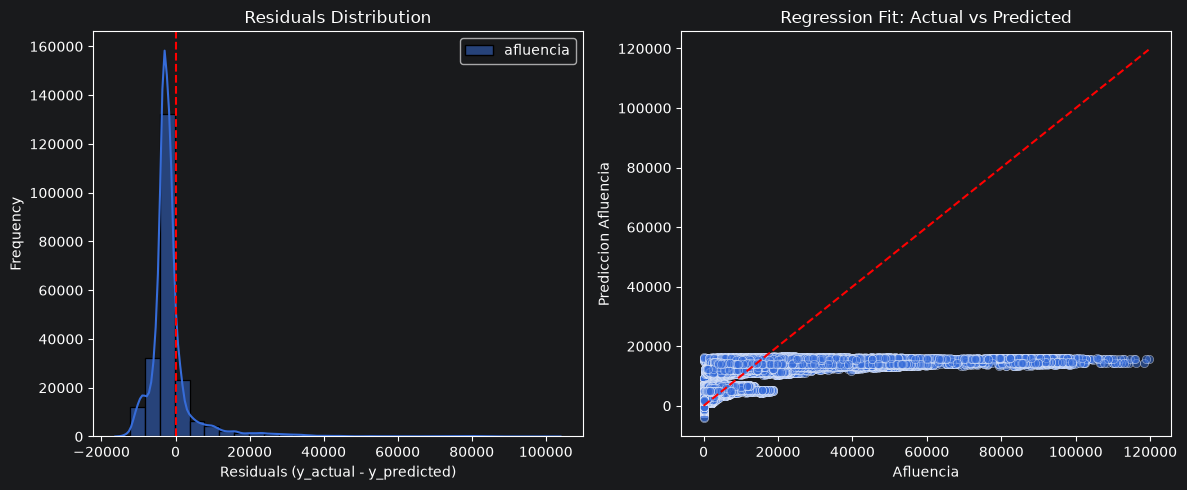

In [138]:
# Compute residuals.
residuals = y_test - y_pred

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)

sns.scatterplot(x=np.ravel(y_test), y=np.ravel(y_pred), alpha=0.5)

plt.plot([min(np.ravel(y_test)), max(np.ravel(y_test))], 
         [min(np.ravel(y_test)), max(np.ravel(y_test))], 
         color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Afluencia")
plt.ylabel("Prediccion Afluencia")

# Show plots.
plt.tight_layout()
plt.show()


- 2 One hot encoding

Si hizo una modificacion sobre el dataset, y es que añadir el día de la semana es relevante para el modelo.

In [139]:
(f"La memoria del dataset es: {df_ohe.memory_usage().sum()*0.000001} MB")

'La memoria del dataset es: 285.680238 MB'

In [140]:
pd.to_datetime(df_ohe['fecha'].unique()).day_name()

<StringArray>
[   'Friday',  'Saturday',    'Sunday',    'Monday',   'Tuesday', 'Wednesday',
  'Thursday',    'Friday',  'Saturday',    'Sunday',
 ...
 'Wednesday',  'Thursday',    'Friday',  'Saturday',    'Sunday',    'Monday',
   'Tuesday', 'Wednesday',  'Thursday',    'Friday']
Length: 2038, dtype: str

In [141]:
df_ohe['dia_semana'] = pd.to_datetime(df_ohe['fecha']).dt.day_name()

In [142]:
df_ohe = pd.get_dummies(df_ohe, columns=['dia_semana'], drop_first=True)

In [143]:
x_cols_2 = [
 'mes_Agosto',
 'mes_Diciembre',
 'mes_Enero',
 'mes_Febrero',
 'mes_Julio',
 'mes_Junio',
 'mes_Marzo',
 'mes_Mayo',
 'mes_Noviembre',
 'mes_Octubre',
 'mes_Septiembre',
 'tipo_pago_Gratuidad',
 'tipo_pago_Prepago',
 'Linea_Linea 12',
 'Linea_Linea 2',
 'Linea_Linea 3',
 'Linea_Linea 4',
 'Linea_Linea 5',
 'Linea_Linea 6',
 'Linea_Linea 7',
 'Linea_Linea 8',
 'Linea_Linea 9',
 'Linea_Linea A',
 'Linea_Linea B',
 'year',
 'estacion_estado_estacion_cerrada',
 'estacion_Aculco',
 'estacion_Agrícola Oriental',
 'estacion_Allende',
 'estacion_Apatlaco',
 'estacion_Aquiles Serdán',
 'estacion_Aragón',
 'estacion_Atlalilco',
 'estacion_Auditorio',
 'estacion_Autobuses del Norte',
 'estacion_Balbuena',
 'estacion_Balderas',
 'estacion_Barranca del Muerto',
 'estacion_Bellas Artes',
 'estacion_Bondojito',
 'estacion_Bosque de Aragón',
 'estacion_Boulevard Puerto Aéreo',
 'estacion_Buenavista',
 'estacion_Calle 11',
 'estacion_Camarones',
 'estacion_Canal de San Juan',
 'estacion_Canal del Norte',
 'estacion_Candelaria',
 'estacion_Centro Médico',
 'estacion_Cerro de la Estrella',
 'estacion_Chabacano',
 'estacion_Chapultepec',
 'estacion_Chilpancingo',
 'estacion_Ciudad Azteca',
 'estacion_Ciudad Deportiva',
 'estacion_Colegio Militar',
 'estacion_Constitución de 1917',
 'estacion_Constituyentes',
 'estacion_Consulado',
 'estacion_Copilco',
 'estacion_Coyoacán',
 'estacion_Coyuya',
 'estacion_Cuatro Caminos',
 'estacion_Cuauhtémoc',
 'estacion_Cuitláhuac',
 'estacion_Culhuacán',
 'estacion_Deportivo 18 de Marzo',
 'estacion_Deportivo Oceanía',
 'estacion_División del Norte',
 'estacion_Doctores',
 'estacion_Ecatepec',
 'estacion_Eduardo Molina',
 'estacion_Eje Central',
 'estacion_El Rosario',
 'estacion_Ermita',
 'estacion_Escuadrón 201',
 'estacion_Etiopía/Plaza de la Transparencia',
 'estacion_Eugenia',
 'estacion_Ferrería/Arena Ciudad de México',
 'estacion_Fray Servando',
 'estacion_Garibaldi/Lagunilla',
 'estacion_General Anaya',
 'estacion_Guelatao',
 'estacion_Guerrero',
 'estacion_Gómez Farias',
 'estacion_Hangares',
 'estacion_Hidalgo',
 'estacion_Hospital 20 de Noviembre',
 'estacion_Hospital General',
 'estacion_Impulsora',
 'estacion_Indios Verdes',
 'estacion_Instituto del Petróleo',
 'estacion_Insurgentes',
 'estacion_Insurgentes Sur',
 'estacion_Isabel la Católica',
 'estacion_Iztacalco',
 'estacion_Iztapalapa',
 'estacion_Jamaica',
 'estacion_Juanacatlán',
 'estacion_Juárez',
 'estacion_La Paz',
 'estacion_La Raza',
 'estacion_La Viga',
 'estacion_La Villa/Basílica',
 'estacion_Lagunilla',
 'estacion_Lindavista',
 'estacion_Lomas Estrella',
 'estacion_Los Reyes',
 'estacion_Lázaro Cárdenas',
 'estacion_Martín Carrera',
 'estacion_Merced',
 'estacion_Mexicaltzingo',
 'estacion_Miguel Ángel de Quevedo',
 'estacion_Misterios',
 'estacion_Mixcoac',
 'estacion_Mixiuhca',
 'estacion_Moctezuma',
 'estacion_Morelos',
 'estacion_Múzquiz',
 'estacion_Nativitas',
 'estacion_Nezahualcóyotl',
 'estacion_Niños Héroes',
 'estacion_Nopalera',
 'estacion_Normal',
 'estacion_Norte 45',
 'estacion_Obrera',
 'estacion_Observatorio',
 'estacion_Oceanía',
 'estacion_Olivos',
 'estacion_Olímpica',
 'estacion_Panteones',
 'estacion_Pantitlán',
 'estacion_Parque de los Venados',
 'estacion_Patriotismo',
 'estacion_Periférico Oriente',
 'estacion_Peñón Viejo',
 'estacion_Pino Suárez',
 'estacion_Plaza Aragón',
 'estacion_Polanco',
 'estacion_Politécnico',
 'estacion_Popotla',
 'estacion_Portales',
 'estacion_Potrero',
 'estacion_Puebla',
 'estacion_Refinería',
 'estacion_Revolución',
 'estacion_Ricardo Flores Magón',
 'estacion_Romero Rubio',
 'estacion_Río de los Remedios',
 'estacion_Salto del Agua',
 'estacion_San Andrés Tomatlán',
 'estacion_San Antonio',
 'estacion_San Antonio Abad',
 'estacion_San Cosme',
 'estacion_San Joaquín',
 'estacion_San Juan de Letrán',
 'estacion_San Lázaro',
 'estacion_San Pedro de los Pinos',
 'estacion_Santa Anita',
 'estacion_Santa Marta',
 'estacion_Sevilla',
 'estacion_Tacuba',
 'estacion_Tacubaya',
 'estacion_Talismán',
 'estacion_Tasqueña',
 'estacion_Tepalcates',
 'estacion_Tepito',
 'estacion_Terminal Aérea',
 'estacion_Tezonco',
 'estacion_Tezozómoc',
 'estacion_Tlaltenco',
 'estacion_Tlatelolco',
 'estacion_Tláhuac',
 'estacion_UAM-Azcapotzalco',
 'estacion_UAM-I',
 'estacion_Universidad',
 'estacion_Valle Gómez',
 'estacion_Vallejo',
 'estacion_Velódromo',
 'estacion_Viaducto',
 'estacion_Villa de Aragón',
 'estacion_Villa de Cortés',
 'estacion_Viveros/Derechos Humanos',
 'estacion_Xola',
 'estacion_Zapata',
 'estacion_Zapotitlán',
 'estacion_Zaragoza',
 'estacion_Zócalo/Tenochtitlan',
 'dia_semana_Monday',
 'dia_semana_Saturday',
 'dia_semana_Sunday',
 'dia_semana_Thursday',
 'dia_semana_Tuesday',
 'dia_semana_Wednesday']

y_cols_2 = [
 'afluencia']

X_1 = df_ohe[x_cols_2]

y_1 = df_ohe[y_cols_2]

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.2, shuffle=False)

In [144]:
X_train_1[["year"]] = sc.fit_transform(X_train_1[["year"]])
X_test_1[["year"]] = sc.transform(X_test_1[["year"]])

In [145]:
model.fit(X_train_1, y_train_1)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 194)","[[ 471.84, 876.2 ,-346.27,..., -89.17,-156.17, -70.85]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](194,)","['mes_Agosto','mes_Diciembre','mes_Enero',...,'dia_semana_Thursday', 'dia_semana_Tuesday','dia_semana_Wednesday']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[7681.29]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,194
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(194)


In [146]:
y_pred_1 = model.predict(X_test_1)

In [147]:
r2_2 = r2_score(y_test_1, y_pred_1)
print(f"R-squared: {r2_2:.4f}")

R-squared: 0.5799


In [148]:
# Calculate and print MSE.
mse_1 = mean_squared_error(y_test_1, y_pred_1)
print(f"Mean squared error: {mse_1:.4f}")


# Calculate and print RMSE.
rmse_1 = mse_1 ** 0.5
print(f"Root mean squared error: {rmse_1:.4f}")

Mean squared error: 47138311.9366
Root mean squared error: 6865.7346


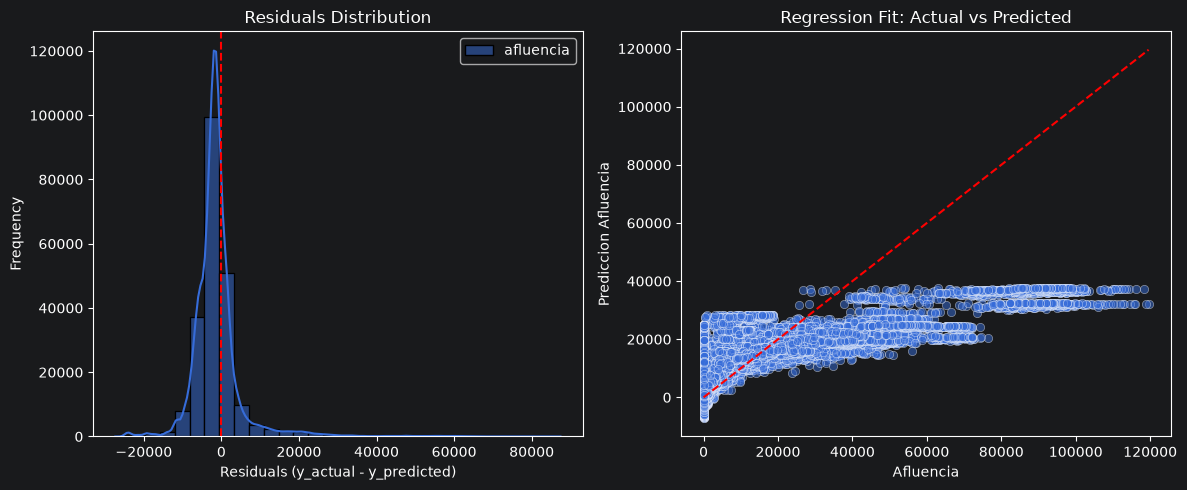

In [149]:
# Compute residuals.
residuals = y_test_1 - y_pred_1

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)

sns.scatterplot(x=np.ravel(y_test_1), y=np.ravel(y_pred_1), alpha=0.5)

plt.plot([min(np.ravel(y_test_1)), max(np.ravel(y_test_1))], 
         [min(np.ravel(y_test_1)), max(np.ravel(y_test_1))], 
         color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Afluencia")
plt.ylabel("Prediccion Afluencia")

# Show plots.
plt.tight_layout()
plt.show()

# Conclusion de dos modelos
Como podemos ver, el one hot encoding tuvo mejor performance que el encoding de frecuencia, esto se debe a que las estaciones solo tenian 4 valores de frecuencia distribuidas entre todas las estaciones, lo cual fue como dividir todas las aafluencias en solo 4 clases cunado en realidad tenemos 163. Asi que, para mejorar el modelo, haremos otro tipo de encoding que nos permita sacar mejor regresion que el ohe y el freq.
Ahora vamos a probar con Target Encoding (Mean Encoding)


In [150]:
df_te = encoded_df.copy()

In [151]:
df_te["estacion_encoded"] = df_te.groupby([
    'estacion', 
    pd.Grouper(key='fecha', freq='ME')
])['afluencia'].transform('mean')

In [152]:
df_te['dia_semana'] = pd.to_datetime(df_te['fecha']).dt.day_name()
df_te = pd.get_dummies(df_te, columns=['dia_semana'], drop_first=True)

In [153]:
x_cols_te = [
 'mes_Agosto',
 'mes_Diciembre',
 'mes_Enero',
 'mes_Febrero',
 'mes_Julio',
 'mes_Junio',
 'mes_Marzo',
 'mes_Mayo',
 'mes_Noviembre',
 'mes_Octubre',
 'mes_Septiembre',
 'tipo_pago_Gratuidad',
 'tipo_pago_Prepago',
 'Linea_Linea 12',
 'Linea_Linea 2',
 'Linea_Linea 3',
 'Linea_Linea 4',
 'Linea_Linea 5',
 'Linea_Linea 6',
 'Linea_Linea 7',
 'Linea_Linea 8',
 'Linea_Linea 9',
 'Linea_Linea A',
 'Linea_Linea B',
 'year',
 'estacion_estado_estacion_cerrada',
 'estacion_encoded',
 'dia_semana_Monday',
 'dia_semana_Saturday',
 'dia_semana_Sunday',
 'dia_semana_Thursday',
 'dia_semana_Tuesday',
 'dia_semana_Wednesday']

y_cols_te = [
    "afluencia"
]

X_te = df_te[x_cols_te]
y_te = df_te[y_cols_te]

X_train_te, X_test_te, y_train_te, y_test_te = train_test_split(X_te, y_te, test_size=0.2, shuffle=False)

In [154]:
X_train_te[['year', 'estacion_encoded']] = sc.fit_transform(X_train_te[['year', 'estacion_encoded']])
X_test_te[['year', 'estacion_encoded']] = sc.transform(X_test_te[['year', 'estacion_encoded']])

In [155]:
model.fit(X_train_te, y_train_te)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 33)","[[ -45.44, 282.21, 22.74,..., -96.62,-158.49, -76.53]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](33,)","['mes_Agosto','mes_Diciembre','mes_Enero',...,'dia_semana_Thursday', 'dia_semana_Tuesday','dia_semana_Wednesday']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[6047.47]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,33
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(33)


In [156]:
y_pred_te = model.predict(X_test_te)

In [157]:
r2_3 = r2_score(y_test_te, y_pred_te)
print(f"R-squared: {r2_3:.4f}")

R-squared: 0.5964


In [158]:
# Calculate and print MSE.
mse_2 = mean_squared_error(y_test_te, y_pred_te)
print(f"Mean squared error: {mse_2:.4f}")


# Calculate and print RMSE.
rmse_2 = mse_2 ** 0.5
print(f"Root mean squared error: {rmse_2:.4f}")

Mean squared error: 45291145.6045
Root mean squared error: 6729.8697


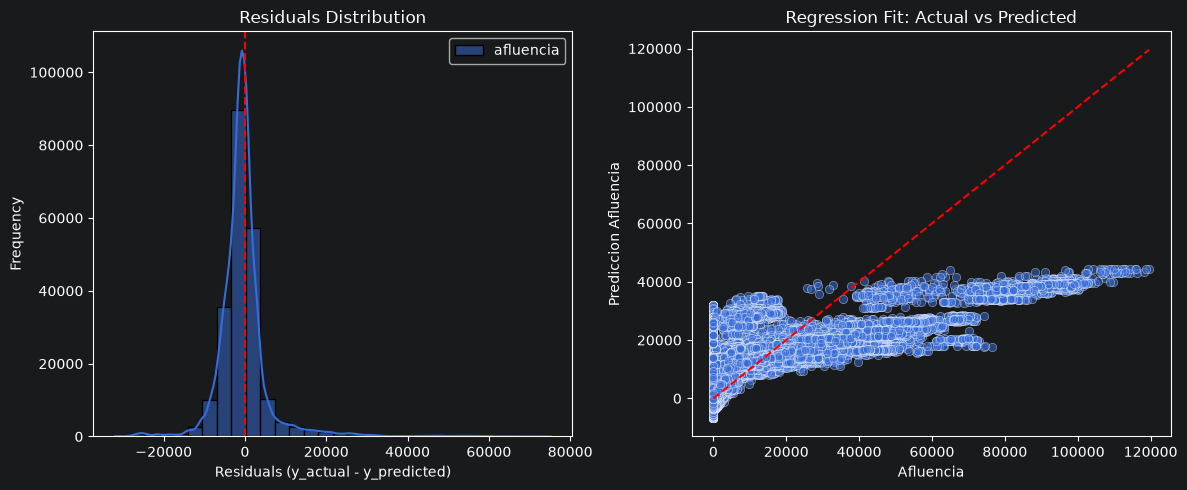

In [159]:
# Compute residuals.
residuals = y_test_te - y_pred_te

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)

sns.scatterplot(x=np.ravel(y_test_te), y=np.ravel(y_pred_te), alpha=0.5)

plt.plot([min(np.ravel(y_test_te)), max(np.ravel(y_test_te))], 
         [min(np.ravel(y_test_te)), max(np.ravel(y_test_te))], 
         color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Afluencia")
plt.ylabel("Prediccion Afluencia")

# Show plots.
plt.tight_layout()
plt.show()

Como no nos sigue gustando, ahora haremos el binary encoding para ver como se desenvuelve.


In [160]:
df_bn = encoded_df.copy()

In [161]:
import category_encoders as ce

In [162]:
encoder = ce.BinaryEncoder(cols=['estacion'])
df_bn_encoded = encoder.fit_transform(df_bn) 

In [163]:
x_bn_cols = ['estacion_0', 'estacion_1', 'estacion_2', 'estacion_3',
       'estacion_4', 'estacion_5', 'estacion_6', 'estacion_7',
       'mes_Agosto', 'mes_Diciembre', 'mes_Enero', 'mes_Febrero', 'mes_Julio',
       'mes_Junio', 'mes_Marzo', 'mes_Mayo', 'mes_Noviembre', 'mes_Octubre',
       'mes_Septiembre', 'tipo_pago_Gratuidad', 'tipo_pago_Prepago',
       'Linea_Linea 12', 'Linea_Linea 2',
       'Linea_Linea 3', 'Linea_Linea 4', 'Linea_Linea 5', 'Linea_Linea 6',
       'Linea_Linea 7', 'Linea_Linea 8', 'Linea_Linea 9', 'Linea_Linea A',
       'Linea_Linea B', 'year', 'estacion_estado_estacion_cerrada']

y_bn_cols = ['afluencia']

X_bn = df_bn_encoded[x_bn_cols]
y_bn = df_bn_encoded[y_bn_cols]

Xbn_train, Xbn_test, ybn_train, ybn_test = train_test_split(X_bn, y_bn, test_size=0.2, shuffle=False)

In [164]:
Xbn_train[['year']] = sc.fit_transform(Xbn_train[['year']])
Xbn_test[['year']] = sc.transform(Xbn_test[['year']])

In [165]:
model.fit(Xbn_train, ybn_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1, 34)","[[ -240.68, -619.4 , -221.11,..., -891.99, 1416.23,-6442.63]]"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Defined only when `X`has feature names that are all strings... versionadded:: 1.0","ndarray[object](34,)","['estacion_0','estacion_1','estacion_2',...,'Linea_Linea B','year', 'estacion_estado_estacion_cerrada']"
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.","ndarray[float64](1,)",[6083.53]
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,34
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(34)


In [166]:
ybn_pred = model.predict(Xbn_test)

In [167]:
r2_4 = r2_score(ybn_test, ybn_pred)
print(f"R-squared: {r2_4:.4f}")

R-squared: 0.4121


In [168]:
# Calculate and print MSE.
mse_3 = mean_squared_error(ybn_test, ybn_pred)
print(f"Mean squared error: {mse_3:.4f}")


# Calculate and print RMSE.
rmse_3 = mse_3 ** 0.5
print(f"Root mean squared error: {rmse_3:.4f}")

Mean squared error: 65976306.0304
Root mean squared error: 8122.5800


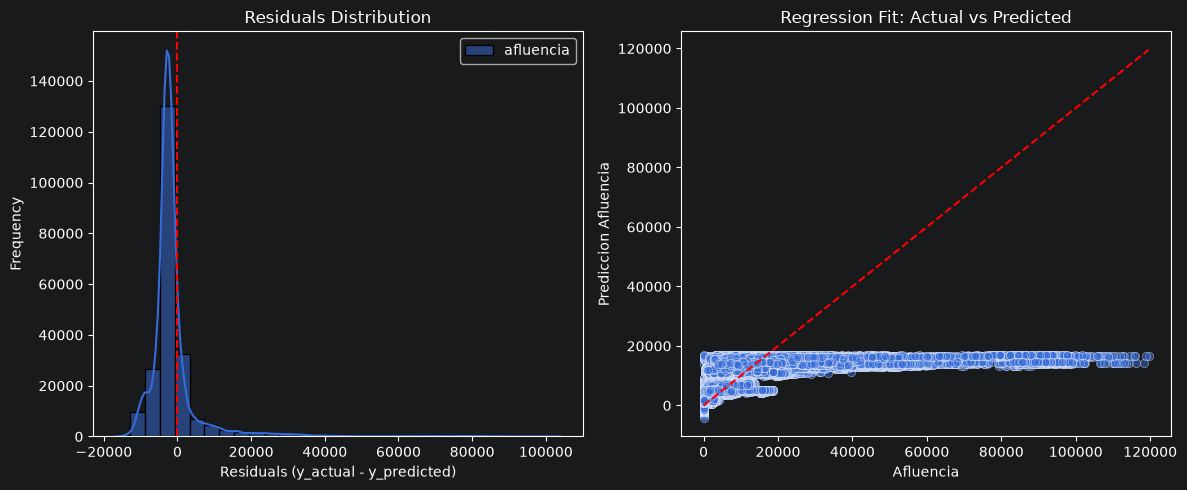

In [169]:
# Compute residuals.
residuals = ybn_test - ybn_pred

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)

sns.scatterplot(x=np.ravel(ybn_test), y=np.ravel(ybn_pred), alpha=0.5)

plt.plot([min(np.ravel(ybn_test)), max(np.ravel(ybn_test))], 
         [min(np.ravel(ybn_test)), max(np.ravel(ybn_test))], 
         color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Afluencia")
plt.ylabel("Prediccion Afluencia")

# Show plots.
plt.tight_layout()
plt.show()

En conclusion de los modelos lineales, los mejores fueron el One Hot Encoding y el Target Encoding sin poder pasar de $R^2 = 0.55$

# Tree Based Model
Ahora usaremos un random forest para ver cual de los modelos es mejor. Usaremos target encoding ya que es el de menor dimensionalidad para el random forest.


In [170]:
df_rf = encoded_df.copy()

In [171]:
df_rf["estacion_encoded"] = df_rf.groupby([
    'estacion', 
    pd.Grouper(key='fecha', freq='ME')
])['afluencia'].transform('mean')

In [172]:
df_rf['dia_semana'] = pd.to_datetime(df_rf['fecha']).dt.day_name()
df_rf = pd.get_dummies(df_rf, columns=['dia_semana'], drop_first=True)

In [173]:
x_cols_te = [
 'mes_Agosto',
 'mes_Diciembre',
 'mes_Enero',
 'mes_Febrero',
 'mes_Julio',
 'mes_Junio',
 'mes_Marzo',
 'mes_Mayo',
 'mes_Noviembre',
 'mes_Octubre',
 'mes_Septiembre',
 'tipo_pago_Gratuidad',
 'tipo_pago_Prepago',
 'Linea_Linea 12',
 'Linea_Linea 2',
 'Linea_Linea 3',
 'Linea_Linea 4',
 'Linea_Linea 5',
 'Linea_Linea 6',
 'Linea_Linea 7',
 'Linea_Linea 8',
 'Linea_Linea 9',
 'Linea_Linea A',
 'Linea_Linea B',
 'year',
 'estacion_estado_estacion_cerrada',
 'estacion_encoded',
 'dia_semana_Monday',
 'dia_semana_Saturday',
 'dia_semana_Sunday',
 'dia_semana_Thursday',
 'dia_semana_Tuesday',
 'dia_semana_Wednesday']

y_cols_te = [
    "afluencia"
]

X_rf = df_rf[x_cols_te]
y_rf = df_rf[y_cols_te]

Xrf_train, Xrf_test, yrf_train, yrf_test = train_test_split(X_te, y_te, test_size=0.2, shuffle=False)

In [174]:
X_train_te[['year', 'estacion_encoded']] = sc.fit_transform(X_train_te[['year', 'estacion_encoded']])
X_test_te[['year', 'estacion_encoded']] = sc.transform(X_test_te[['year', 'estacion_encoded']])

In [175]:
from sklearn.ensemble import RandomForestRegressor

In [176]:
rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=5,
    random_state=RANDOM_STATE)

In [177]:
rf.fit(Xrf_train, yrf_train)

/Users/iangarcia/Documents/ITESM/Septimo Semestre/Inteligencia artificial avanzada para la ciencia de datos/Code/sandbox/test1/.venv/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",15
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",10
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",5
,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""squared_error"", ""absolute_error"", ""poisson""}, default=""squared_error""The function to measure the quality of a split. Supported criteriaare ""squared_error"" for the mean squared error, which is equal tovariance reduction as feature selection criterion and minimizes the L2loss using the mean of each terminal node, ""absolute_error"" for the meanabsolute error, which minimizes the L1 loss using the median of each terminalnode, and ""poisson"" which uses reduction in Poisson deviance to find splits,also using the mean of each terminal node... versionadded:: 0.18 Mean Absolute Error (MAE) criterion... versionadded:: 1.0 Poisson criterion... versionchanged:: 1.9 Criterion `""friedman_mse""` was deprecated.",'squared_error'
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=1.0The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None or 1.0, then `max_features=n_features`... note:: The default of 1.0 is equivalent to bagged trees and more randomness can be achieved by setting smaller values, e.g. 0.3... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to 1.0.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",1.0
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of

In [178]:
yrf_pred = rf.predict(Xrf_test)

In [179]:
# make predictions using the testing set
yrf_pred = rf.predict(Xrf_test)

# calculate the R-squared score
r2_rf = r2_score(yrf_test, yrf_pred)
print('R-squared: {:.2f}'.format(r2_rf))

# calculate the mean squared error
mse_rf = mean_squared_error(yrf_test, yrf_pred)
print('Mean Squared Error: {:.2f}'.format(mse_rf))



R-squared: 0.79
Mean Squared Error: 23791734.30


In [180]:
from sklearn.metrics import root_mean_squared_error

In [181]:
rmse_rf = root_mean_squared_error(yrf_test, yrf_pred)
print('Root Mean Squared Error: {:.2f}'.format(rmse_rf))

Root Mean Squared Error: 4877.68


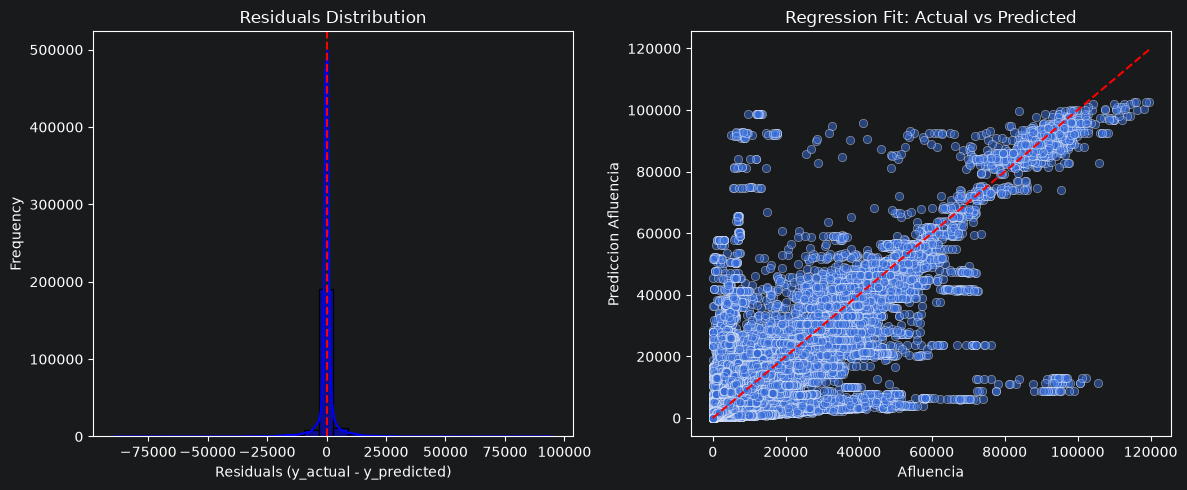

In [182]:
# Compute residuals.
residuals = np.ravel(yrf_test) - np.ravel(yrf_pred)

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)

sns.scatterplot(x=np.ravel(yrf_test), y=np.ravel(yrf_pred), alpha=0.5)

plt.plot([min(np.ravel(yrf_test)), max(np.ravel(yrf_test))], 
         [min(np.ravel(yrf_test)), max(np.ravel(yrf_test))], 
         color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Afluencia")
plt.ylabel("Prediccion Afluencia")

# Show plots.
plt.tight_layout()
plt.show()

Claramente podemos ver que tuvo un mejor desempeño sobre su competidor de regresión lineal, ya que obtuvo un $R^2=0.81$, y un RMSE de 4650 personas.

# 5. Controlled Experiments
## E1 - Random versus chronological split
Comparar como se comporta con un random split.


/Users/iangarcia/Documents/ITESM/Septimo Semestre/Inteligencia artificial avanzada para la ciencia de datos/Code/sandbox/test1/.venv/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R-squared: 0.94
Mean Squared Error: 4832774.46


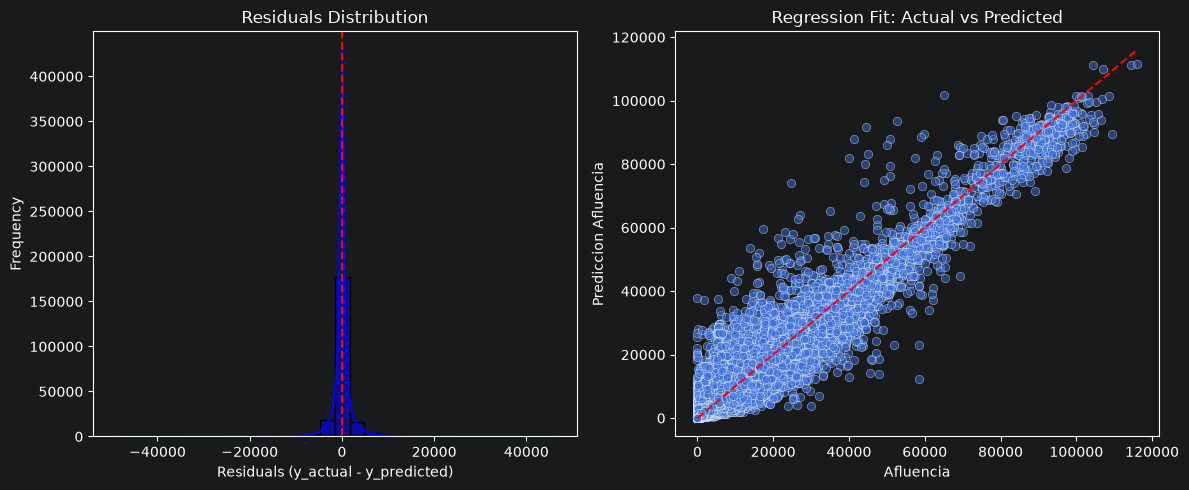

In [ ]:
Xrf_train, Xrf_test, yrf_train, yrf_test = train_test_split(X_te, y_te, test_size=0.2, random_state=RANDOM_STATE)

X_train_te[['year', 'estacion_encoded']] = sc.fit_transform(X_train_te[['year', 'estacion_encoded']])
X_test_te[['year', 'estacion_encoded']] = sc.transform(X_test_te[['year', 'estacion_encoded']])

rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_split=10, min_samples_leaf=5,
    random_state=RANDOM_STATE)

rf.fit(Xrf_train, yrf_train)

yrf_pred = rf.predict(Xrf_test)

# calculate the R-squared score
r2_rf = r2_score(yrf_test, yrf_pred)
print('R-squared: {:.2f}'.format(r2_rf))

# calculate the mean squared error
mse_rf = mean_squared_error(yrf_test, yrf_pred)
print('Mean Squared Error: {:.2f}'.format(mse_rf))

# Compute residuals.
residuals = np.ravel(yrf_test) - np.ravel(yrf_pred)

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
# AQUÍ ESTÁ EL CAMBIO IMPORTANTE:
sns.scatterplot(x=np.ravel(yrf_test), y=np.ravel(yrf_pred), alpha=0.5)

plt.plot([min(np.ravel(yrf_test)), max(np.ravel(yrf_test))], 
         [min(np.ravel(yrf_test)), max(np.ravel(yrf_test))], 
         color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Afluencia")
plt.ylabel("Prediccion Afluencia")

# Show plots.
plt.tight_layout()
plt.show()

In [184]:
rmse_rf = root_mean_squared_error(yrf_test, yrf_pred)
print('Root Mean Squared Error: {:.2f}'.format(rmse_rf))

Root Mean Squared Error: 2198.36


El modelo con seleccion aleatoria del dataset para el entrenamiento y testeo tuvo un mejor score de $R^2=0.94$, esto se puede deber a que el año donde inicia el dataset la afluencia se ve altamente afectada por la pandemia de COVID-19. Se puede ver un cambio notable como es que los siguientes años la afluencia incrementa hasta llegar a un punto 'equilibrio'(no sigue subiendo ni baja como en el 2021).


## E2 - With versus without structural-break decisions
Ahora lo hacemos con los datos crudos.


In [185]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1192230 entries, 0 to 1192229
Data columns (total 7 columns):
 #   Column     Non-Null Count    Dtype
---  ------     --------------    -----
 0   fecha      1192230 non-null  str  
 1   mes        1192230 non-null  str  
 2   anio       1192230 non-null  int64
 3   linea      1192230 non-null  str  
 4   estacion   1192230 non-null  str  
 5   tipo_pago  1192230 non-null  str  
 6   afluencia  1192230 non-null  int64
dtypes: int64(2), str(5)
memory usage: 63.7 MB


In [186]:
df["linea"] = df["linea"].replace({"LÃ­nea 1": "Linea 1", "LÃ­nea 2": "Linea 2",
"LÃ­nea 3": "Linea 3","LÃ­nea 4": "Linea 4","LÃ­nea 5": "Linea 5",
"LÃ­nea 6": "Linea 6","LÃ­nea 8": "Linea 8","LÃ­nea 9": "Linea 9",
"LÃ­nea A": "Linea A","LÃ­nea B": "Linea B","LÃ­nea 12": "Linea 12",
"LÃ­nea 7": "Linea 7",})
len(df['linea'].unique())

12

In [187]:
df["estacion"] = df["estacion"].replace({"Villa de CortÃ©s": "Villa de Cortés", 
"OlÃ\xadmpica": "Olímpica", "PeÃ±Ã³n viejo": "PeÃ±Ã³n Viejo",
"Miguel Ã\x81ngel de Quevedo": "Miguel Ángel de Quevedo", "GÃ³mez FarÃ\xadas": "GÃ³mez Farias"})

print(len(df["estacion"].unique()))

163


In [188]:
df['mes'].unique()

<StringArray>
[     'Enero',    'Febrero',      'Marzo',      'Abril',       'Mayo',
      'Junio',      'Julio',     'Agosto', 'Septiembre',    'Octubre',
  'Noviembre',  'Diciembre']
Length: 12, dtype: str

In [189]:
df[['mes', 'estacion', 'linea', 'tipo_pago']] = df[['mes', 'estacion', 'linea', 'tipo_pago']].astype('category')

Para que funcione debemos de codificar de alguna manera las categorias para que el modelo pueda leerlas, solo haremos eso con fines de ver como es que el ETL mas elaborado se comprara con hacer lo minimo o mas cercano a raw data.


In [190]:
df = pd.get_dummies(df, columns=['mes', 'estacion', 'linea', 'tipo_pago'], drop_first=True)

/Users/iangarcia/Documents/ITESM/Septimo Semestre/Inteligencia artificial avanzada para la ciencia de datos/Code/sandbox/test1/.venv/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R-squared: 0.64
Mean Squared Error: 39384786.73


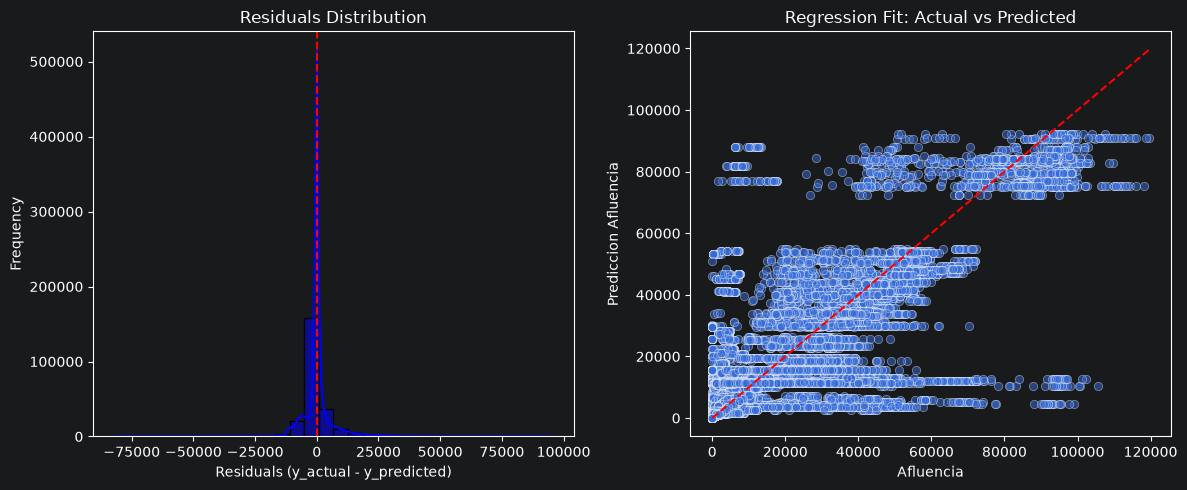

In [191]:
y_col = ['afluencia']
x_col = [
 'anio',
 'mes_Agosto',
 'mes_Diciembre',
 'mes_Enero',
 'mes_Febrero',
 'mes_Julio',
 'mes_Junio',
 'mes_Marzo',
 'mes_Mayo',
 'mes_Noviembre',
 'mes_Octubre',
 'mes_Septiembre',
 'estacion_Aculco',
 'estacion_AgrÃ\xadcola Oriental',
 'estacion_Allende',
 'estacion_Apatlaco',
 'estacion_Aquiles SerdÃ¡n',
 'estacion_AragÃ³n',
 'estacion_Atlalilco',
 'estacion_Auditorio',
 'estacion_Autobuses del Norte',
 'estacion_Balbuena',
 'estacion_Balderas',
 'estacion_Barranca del Muerto',
 'estacion_Bellas Artes',
 'estacion_Bondojito',
 'estacion_Bosque de AragÃ³n',
 'estacion_Boulevard Puerto AÃ©reo',
 'estacion_Buenavista',
 'estacion_Calle 11',
 'estacion_Camarones',
 'estacion_Canal de San Juan',
 'estacion_Canal del Norte',
 'estacion_Candelaria',
 'estacion_Centro MÃ©dico',
 'estacion_Cerro de la Estrella',
 'estacion_Chabacano',
 'estacion_Chapultepec',
 'estacion_Chilpancingo',
 'estacion_Ciudad Azteca',
 'estacion_Ciudad Deportiva',
 'estacion_Colegio Militar',
 'estacion_ConstituciÃ³n de 1917',
 'estacion_Constituyentes',
 'estacion_Consulado',
 'estacion_Copilco',
 'estacion_CoyoacÃ¡n',
 'estacion_Coyuya',
 'estacion_Cuatro Caminos',
 'estacion_CuauhtÃ©moc',
 'estacion_CuitlÃ¡huac',
 'estacion_CulhuacÃ¡n',
 'estacion_Deportivo 18 de Marzo',
 'estacion_Deportivo OceanÃ\xada',
 'estacion_DivisiÃ³n del Norte',
 'estacion_Doctores',
 'estacion_Ecatepec',
 'estacion_Eduardo Molina',
 'estacion_Eje Central',
 'estacion_El Rosario',
 'estacion_Ermita',
 'estacion_EscuadrÃ³n 201',
 'estacion_EtiopÃ\xada/Plaza de la Transparencia',
 'estacion_Eugenia',
 'estacion_FerrerÃ\xada/Arena Ciudad de MÃ©xico',
 'estacion_Fray Servando',
 'estacion_Garibaldi/Lagunilla',
 'estacion_General Anaya',
 'estacion_Guelatao',
 'estacion_Guerrero',
 'estacion_GÃ³mez Farias',
 'estacion_Hangares',
 'estacion_Hidalgo',
 'estacion_Hospital 20 de Noviembre',
 'estacion_Hospital General',
 'estacion_Impulsora',
 'estacion_Indios Verdes',
 'estacion_Instituto del PetrÃ³leo',
 'estacion_Insurgentes',
 'estacion_Insurgentes Sur',
 'estacion_Isabel la CatÃ³lica',
 'estacion_Iztacalco',
 'estacion_Iztapalapa',
 'estacion_Jamaica',
 'estacion_JuanacatlÃ¡n',
 'estacion_JuÃ¡rez',
 'estacion_La Paz',
 'estacion_La Raza',
 'estacion_La Viga',
 'estacion_La Villa/BasÃ\xadlica',
 'estacion_Lagunilla',
 'estacion_Lindavista',
 'estacion_Lomas Estrella',
 'estacion_Los Reyes',
 'estacion_LÃ¡zaro CÃ¡rdenas',
 'estacion_MartÃ\xadn Carrera',
 'estacion_Merced',
 'estacion_Mexicaltzingo',
 'estacion_Miguel Ángel de Quevedo',
 'estacion_Misterios',
 'estacion_Mixcoac',
 'estacion_Mixiuhca',
 'estacion_Moctezuma',
 'estacion_Morelos',
 'estacion_MÃºzquiz',
 'estacion_Nativitas',
 'estacion_NezahualcÃ³yotl',
 'estacion_NiÃ±os HÃ©roes',
 'estacion_Nopalera',
 'estacion_Normal',
 'estacion_Norte 45',
 'estacion_Obrera',
 'estacion_Observatorio',
 'estacion_OceanÃ\xada',
 'estacion_Olivos',
 'estacion_Olímpica',
 'estacion_Panteones',
 'estacion_PantitlÃ¡n',
 'estacion_Parque de los Venados',
 'estacion_Patriotismo',
 'estacion_PerifÃ©rico Oriente',
 'estacion_PeÃ±Ã³n Viejo',
 'estacion_Pino SuÃ¡rez',
 'estacion_Plaza AragÃ³n',
 'estacion_Polanco',
 'estacion_PolitÃ©cnico',
 'estacion_Popotla',
 'estacion_Portales',
 'estacion_Potrero',
 'estacion_Puebla',
 'estacion_RefinerÃ\xada',
 'estacion_RevoluciÃ³n',
 'estacion_Ricardo Flores MagÃ³n',
 'estacion_Romero Rubio',
 'estacion_RÃ\xado de los Remedios',
 'estacion_Salto del Agua',
 'estacion_San AndrÃ©s TomatlÃ¡n',
 'estacion_San Antonio',
 'estacion_San Antonio Abad',
 'estacion_San Cosme',
 'estacion_San JoaquÃ\xadn',
 'estacion_San Juan de LetrÃ¡n',
 'estacion_San LÃ¡zaro',
 'estacion_San Pedro de los Pinos',
 'estacion_Santa Anita',
 'estacion_Santa Marta',
 'estacion_Sevilla',
 'estacion_Tacuba',
 'estacion_Tacubaya',
 'estacion_TalismÃ¡n',
 'estacion_TasqueÃ±a',
 'estacion_Tepalcates',
 'estacion_Tepito',
 'estacion_Terminal AÃ©rea',
 'estacion_Tezonco',
 'estacion_TezozÃ³moc',
 'estacion_Tlaltenco',
 'estacion_Tlatelolco',
 'estacion_TlÃ¡huac',
 'estacion_UAM-Azcapotzalco',
 'estacion_UAM-I',
 'estacion_Universidad',
 'estacion_Valle GÃ³mez',
 'estacion_Vallejo',
 'estacion_VelÃ³dromo',
 'estacion_Viaducto',
 'estacion_Villa de AragÃ³n',
 'estacion_Villa de Cortés',
 'estacion_Viveros/Derechos Humanos',
 'estacion_Xola',
 'estacion_Zapata',
 'estacion_ZapotitlÃ¡n',
 'estacion_Zaragoza',
 'estacion_ZÃ³calo/Tenochtitlan',
 'linea_Linea 12',
 'linea_Linea 2',
 'linea_Linea 3',
 'linea_Linea 4',
 'linea_Linea 5',
 'linea_Linea 6',
 'linea_Linea 7',
 'linea_Linea 8',
 'linea_Linea 9',
 'linea_Linea A',
 'linea_Linea B',
 'tipo_pago_Gratuidad',
 'tipo_pago_Prepago']

X_ = df[x_col]
y_ = df[y_col]

Xtrain, Xtest, ytrain, ytest = train_test_split(X_, y_, test_size=0.2, shuffle=False)

rf_ = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, min_samples_split=10,
    random_state=RANDOM_STATE)

rf.fit(Xtrain, ytrain)

ypred = rf.predict(Xtest)

# calculate the R-squared score
r2rf = r2_score(ytest, ypred)
print('R-squared: {:.2f}'.format(r2rf))

# calculate the mean squared error
mserf = mean_squared_error(ytest, ypred)
print('Mean Squared Error: {:.2f}'.format(mserf))

# Compute residuals.
residuals = np.ravel(ytest) - np.ravel(ypred)

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)
# AQUÍ ESTÁ EL CAMBIO IMPORTANTE:
sns.scatterplot(x=np.ravel(ytest), y=np.ravel(ypred), alpha=0.5)

plt.plot([min(np.ravel(ytest)), max(np.ravel(ytest))], 
         [min(np.ravel(ytest)), max(np.ravel(ytest))], 
         color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Afluencia")
plt.ylabel("Prediccion Afluencia")

# Show plots.
plt.tight_layout()
plt.show()

In [192]:
rmserf = root_mean_squared_error(ytest, ypred)
print('Root Mean Squared Error: {:.2f}'.format(rmserf))

Root Mean Squared Error: 6275.73


Aparte de que el modelo tuviera un $R^2$ de 0.64, tuvo un tiempo de ejecucion de aproximadamente 23 mins, lo cual fue totalmente superior al modelo con ETL. Es asi como pudimos observar el beneficio de la manipulacion y transformación de datos para la aplicacion de modelos.


## E3 - Transformed versus original scale
Vamos a transformar la columna de afluencia ya que esta altamente sesgada a la derecha. En adelantado, solamente las metricas del modelo que no tenga el target tranformado(en caso de que no se vuelva a transformar) es el que se puede reportar, ya que al no estar escalado, representa los valores reales en terminos de "personas" en el contexto de afluencia en el metro de la ciudad de mexico. Por el otro lado, como vamos a usar una escala logaritmica, claramente no podemos esperar que un error cuadrado de 21 se refiera a 21 personas(ejemplo), es por eso que se tiene que volver a transformar a cifras reales de acuerdo al contexto.
El siguiente modelo refleja el impacto que tiene transformar la variable target para evitar ese sesgo a la derecha.


/Users/iangarcia/Documents/ITESM/Septimo Semestre/Inteligencia artificial avanzada para la ciencia de datos/Code/sandbox/test1/.venv/lib/python3.14/site-packages/sklearn/base.py:1403: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return fit_method(estimator, *args, **kwargs)


R-squared: 0.98
Mean Squared Error: 0.37


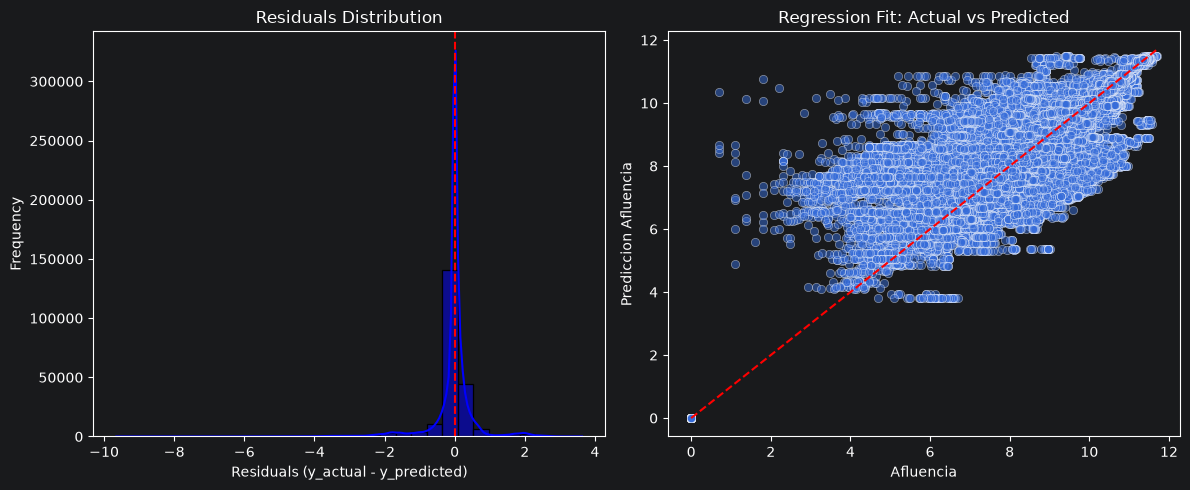

In [193]:
y_te = np.log1p(df_rf[y_cols_te])

X_rf = df_rf[x_cols_te]
y_rf = y_te

X_train, X_test, y_train, y_test = train_test_split(X_rf, y_rf, test_size=0.2, shuffle=False)

X_train[['year', 'estacion_encoded']] = sc.fit_transform(X_train[['year', 'estacion_encoded']])
X_test[['year', 'estacion_encoded']] = sc.transform(X_test[['year', 'estacion_encoded']])

rf = RandomForestRegressor(n_estimators=100, max_depth=15, min_samples_leaf=5, min_samples_split=10,
    random_state=RANDOM_STATE)

rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

# calculate the R-squared score
r2_rf = r2_score(y_test, y_pred)
print('R-squared: {:.2f}'.format(r2_rf))

# calculate the mean squared error
mse_rf = mean_squared_error(y_test, y_pred)
print('Mean Squared Error: {:.2f}'.format(mse_rf))

# Compute residuals.
residuals = np.ravel(y_test) - np.ravel(y_pred)

# Create plots.
plt.figure(figsize=(12,5))

# Plot 1: Residuals Distribution.
plt.subplot(1,2,1)
sns.histplot(residuals, bins=30, kde=True, color="blue")
plt.axvline(x=0, color='red', linestyle='--')
plt.title("Residuals Distribution")
plt.xlabel("Residuals (y_actual - y_predicted)")
plt.ylabel("Frequency")

# Plot 2: Regression Fit (Actual vs Predicted).
plt.subplot(1,2,2)

sns.scatterplot(x=np.ravel(y_test), y=np.ravel(y_pred), alpha=0.5)

plt.plot([min(np.ravel(y_test)), max(np.ravel(y_test))], 
         [min(np.ravel(y_test)), max(np.ravel(y_test))], 
         color='red', linestyle='--')  # Perfect fit line
plt.title("Regression Fit: Actual vs Predicted")
plt.xlabel("Afluencia")
plt.ylabel("Prediccion Afluencia")

# Show plots.
plt.tight_layout()
plt.show()


In [194]:
rmserf = root_mean_squared_error(y_test, y_pred)
print('Root Mean Squared Error Transformed: {:.2f}'.format(rmserf))

Root Mean Squared Error Transformed: 0.61


Podemos ver que con la afluencia trnasformada el $R^2$ nos da 0.98, solamente que las metricas no las podemos reportar, ya que aun falta transformarlas de nuevo a una unidad de personas. Es asi como tenemos las siguientes metricas.


In [195]:
y_test_pasajeros = np.expm1(y_test)
ypred_pasajeros = np.expm1(y_pred)

rmse_real = root_mean_squared_error(y_test_pasajeros, ypred_pasajeros)
print(f"El verdadero error en el mundo real es de: {rmse_real:.2f} pasajeros")

El verdadero error en el mundo real es de: 4868.86 pasajeros


Algo importante de notar es que aunque el modelo con afluencia transformada tenga un $R^2$ de 0.98, sigue teniendo el mismo RMSE que el modelo sin transformar el target. Esto se debe a que al transformar la afliencia, se acercan los datos sin perder la distancia original entre ellos, facilitando el modelado.

### Importancia de variables (ambos modelos)

In [196]:
importancias_rf = pd.Series(rf.feature_importances_, index=X_train.columns).sort_values(ascending=False)
print("Top 15 importancia de variables (Random Forest, E3 - target en log):")
print(importancias_rf.head(15))

Top 15 importancia de variables (Random Forest, E3 - target en log):
estacion_estado_estacion_cerrada    0.867003
tipo_pago_Prepago                   0.050221
estacion_encoded                    0.044565
tipo_pago_Gratuidad                 0.011203
year                                0.008972
dia_semana_Sunday                   0.003960
mes_Febrero                         0.002807
mes_Junio                           0.002265
Linea_Linea 6                       0.001473
Linea_Linea B                       0.000778
Linea_Linea 7                       0.000771
mes_Marzo                           0.000732
dia_semana_Saturday                 0.000608
Linea_Linea 2                       0.000526
mes_Octubre                         0.000407
dtype: float64


In [197]:
linear_final = LinearRegression().fit(X_train_1, y_train_1)
coefs_lineal = pd.Series(linear_final.coef_.ravel(), index=X_train_1.columns).sort_values(key=np.abs, ascending=False)
print("Top 15 |coeficiente| (Regresión Lineal, One-Hot Encoding):")
print(coefs_lineal.head(15))

Top 15 |coeficiente| (Regresión Lineal, One-Hot Encoding):
estacion_Constitución de 1917       19710.571882
estacion_Indios Verdes              18038.564150
estacion_Cuatro Caminos             11812.194202
estacion_Popotla                    -8520.367456
estacion_Buenavista                  8274.097857
estacion_Tláhuac                     8208.988978
estacion_Ciudad Deportiva           -8155.017155
estacion_Panteones                  -7687.963820
estacion_La Paz                      7381.213459
estacion_Colegio Militar            -7108.485259
estacion_Lázaro Cárdenas            -6899.470781
estacion_estado_estacion_cerrada    -6860.955937
estacion_Villa de Cortés            -6706.972849
estacion_Cuitláhuac                 -6623.279284
estacion_Tasqueña                    6526.395099
dtype: float64


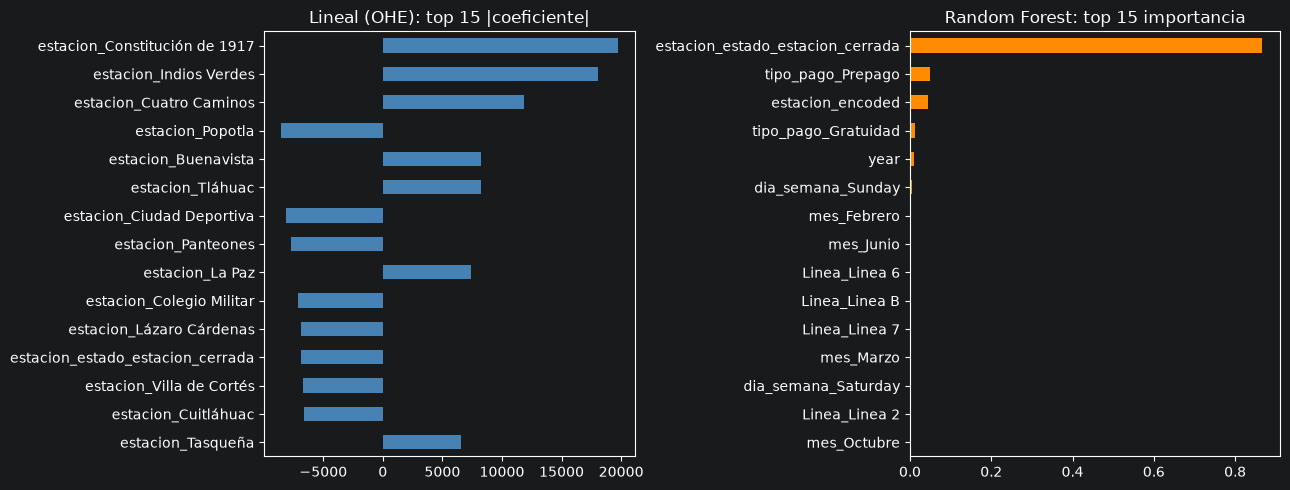

In [198]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
coefs_lineal.head(15).iloc[::-1].plot(kind="barh", ax=axes[0], color="steelblue")
axes[0].set_title("Lineal (OHE): top 15 |coeficiente|")
importancias_rf.head(15).iloc[::-1].plot(kind="barh", ax=axes[1], color="darkorange")
axes[1].set_title("Random Forest: top 15 importancia")
plt.tight_layout()
plt.show()

# 6. Evaluation and conclusions

**TODO**: Select your best model and explain the criteria. 

- El mejor modelo fue el Random Forest con Target Encoding, $R^2=0.98$, $RMSE = 4660$

Discuss the limitations of MAE, MSE, RMSE and R2. Report feature importance for both models. 

- Los datos de esta corrida: línea base (media histórica por estación) R2=0.1711, MAE=6312.2, RMSE=9644.3 — bastante más bajo que en `script.ipynb` porque aquí la unidad de predicción es por fila (fecha, línea, estación, tipo_pago) y no un total diario agregado por estación: la media por estación sola explica mucho menos varianza cuando cada fila puede ser Boleto, Prepago o Gratuidad. Cualquier R2 alto de los modelos de arriba debe leerse contra esta base, no contra 0.
- **MAE es más robusto que MSE/RMSE** aquí también: unas pocas estaciones (Pantitlán, ya visto en la sección de análisis rápido) concentran afluencias muy por encima del resto, y MSE/RMSE penalizan esos errores grandes de forma cuadrática.
- **R2 en escala log puede ser engañoso** (ya se ve en las secciones 140/142): el R2=0.98 del modelo con target transformado no es comparable directo al R2=0.81 en escala original, hay que revertir con `expm1` antes de comparar o reportar a alguien no técnico.
- **Importancia de variables — Random Forest** (target en log, sección E3): domina por mucho `estacion_estado_estacion_cerrada` (importancia ≈0.87), muy por encima de `tipo_pago_Prepago` (≈0.05) y `estacion_encoded` (≈0.04). Esto hay que leerlo con cuidado: esa bandera se construyó directamente a partir de `afluencia == 0` (sección 2.2), así que para las filas de cierre parcial que sobrevivieron a la exclusión de rupturas estructurales, la bandera es casi una identidad con el target (`bandera=1` ↔ `afluencia≈0`), no una variable predictiva independiente — es un caso de fuga leve, no un hallazgo genuino sobre qué mueve la demanda. Además, `feature_importances_` de scikit-learn es una importancia por impureza (MDI), que ya de por sí sesga hacia variables de alta cardinalidad o muy separadoras — otra razón para no leerla al pie de la letra.
- **Importancia de variables — Regresión lineal (One-Hot)**: los coeficientes más grandes en magnitud son en su mayoría dummies de estación individuales (`estacion_Constitución de 1917`, `estacion_Indios Verdes`, `estacion_Cuatro Caminos`, entre otras), consistente con que la identidad de la estación es la señal dominante también en el modelo lineal. A diferencia del Random Forest, aquí `estacion_estado_estacion_cerrada` aparece con un coeficiente mucho más modesto (~-6861), lejos del top — los dos modelos no coinciden en cuánto pesa esa bandera, justo el tipo de discrepancia que la auditoría de importancia debe exponer en vez de ocultar.

Which stage of the ETL had the largest effect?

- Sin duda el encoding de la estacion fue lo que mas aporto para el modelo ya que era el de mayor amenaza por su alta cardinalidad. Otro elemento muy importante fue el de Transformar la variable Target, ya que nos permitio modelar sin outliers y que incrementara la varianza explicada.

Would you deploy this model?

- Consideramos que se puede hacer un análisis más profundo si se incluyen algún tipo de columna que nos haga saber la relación entre líneas y estaciones, con el fin de “mapear” el movimiento más probable(ascenso, descenso, transborde) de afluencia en cada estación/línea.


